# Data Exploration Challenge

For this project, I imported the data avaialable at:

https://github.com/Welltory/hrv-covid19/tree/master

My central question was: How do weather conditions (average temperature, precipitation, and humidity) correlate with daily step counts?
This focus was chosen for two reasons:
Data quality – weather data were consistently filled across entries, making them a reliable anchor.
Intuitive relationship – daily steps are a robust, widely collected behavioral measure that plausibly varies with weather. While not perfect, step counts provide enough variance across time and users to explore meaningful correlations.
I further extended the analysis by creating new features (e.g., deviation from baseline and weekday/weekend averages), which allowed exploration of behavioral trends beyond raw step counts.

```
- Understand your data - what do the features mean? (May have to do some info gathering)
- Document data context and data sampling in markdown
- Explore and interpret data structure, descriptive statistics, data quality, and variable relationships
- Explore data visually with appropriate visualizations
- Discuss and implement strategies for Handling Missing Values, Removing Duplicates, and Handling Outliers
- Perform data transformation as appropriate
- Create at least one new feature and document your approach
- Include a discussion around data quality assessment, including data profiling, data completeness, data accuracy, data consistency, data integrity, and data lineage and provenance
- **IMPORTANT: provide rationale for choices**
```

# Understanding The Data

The dataset is composed of several CSV files. Each file contains an anonymized user identifier (`user_code`) and a date (`day`), enabling cross-linkage across data types.
Core Datasets Used
`weather.csv` – provides daily average temperature, precipitation intensity, humidity, and other environmental features.
`wearables.csv` – provides wearable-derived metrics including daily steps, heart rate, and calories burned.
These two files were prioritized because they directly enable testing the weather–activity hypothesis.

## Biometric Data

Our participants were monitored for biometric data as part of this study. Each is featurized in different mechanisms.

### Blood Pressure
Daily reported diastolic and systolic pressures with corresponding computions of functional changes from baseline, circulatory efficiency, kerdo vegetation index, and robinson index.

### Heart Rate

Throughout the day, heart rates were sampled with additional indications if the user was at rest (0) or not at rest (1).

### Heart Rate Variability

Across users heart rate variability was measured with time for running data sets, with heart rate, mean difference between beats, max, standard deviation, root mean squared, mode, percentage of beat-to-beat gaps that deviated outside of 50% range of average, and power broken up by low, high, very low, and differences between high and low ranges. Finally, total power supplied by the heart was generated. Survery information for participant feeling, sleep score, and other tags are included.

The raw data of the intervals between heart rates was also calculated.

### Sleep

Sleep information was collected for total time spent asleep as well as breaking up sleep into light, deep, and rem sleep with average pulses calculated in the time.

## Other Data:
Notably `participants.csv`, `scales_description.csv`, and `surveys.csv` includes respectively information relating to participant demographic information, the scales used in our surveys and then individual survey responses for their sleep quality.


# Explore and interpret data structure, descriptive statistics, data quality, and variable relationships

From here on out we will focus just on our two primary databases used in this analysis. The first of which is `weather.csv` and `wearables.csv`.

## Data Structure

Tables and descriptions are copied from original GitHub:

https://github.com/Welltory/hrv-covid19/blob/master/datatypes.md
### weather.csv

**data/weather.csv**

Contains data about weather conditions for user's location aggregated by day

|    | Column               | Description                              | Units                  |
|----|----------------------|------------------------------------------|------------------------|
|  0 | user_code            | Unique user ID                           |                        |
|  1 | day                  | Measurement date in YYYY-MM-DD format    |                        |
|  2 | avg_temperature_C    | Outdoor air temperature                  | °C                     |
|  3 | atmospheric_pressure | Atmospheric pressure                     | millimeters of mercury |
|  4 | precip_intensity     | Precipitation                            | millimeters per hour   |
|  5 | humidity             | Outdoor humidity                         | %                      |
|  6 | clouds               | Cloudiness                               | %                      |

### wearables.csv

**data/wearables.csv**

Contains data collected from supported gadgets and aggregated by day

|     |                                     |                                                                                                                                  |                  |
|-----|-------------------------------------|----------------------------------------------------------------------------------------------------------------------------------|------------------|
|     | **Column**                          | **Description**                                                                                                                  | **Units**        |
| 0   | user\_code                          | Unique user ID                                                                                                                   |                  |
| 1   | day                                 | Measurement date in YYYY-MM-DD format                                                                                            |                  |
| 2   | resting\_pulse                      | Resting heart rate                                                                                                               | beats per minute |
| 3   | pulse\_average                      | Heart rate                                                                                                                       | beats per minute |
| 4   | pulse\_min                          | Min heart rate                                                                                                                   | beats per minute |
| 5   | pulse\_max                          | Max heart rate                                                                                                                   | beats per minute |
| 6   | average\_spo2\_value                | Oxygen saturation                                                                                                                | %                |
| 7   | body\_temperature\_avg              | Body temperature                                                                                                                 | °C               |
| 8   | stand\_hours\_total                 | Hours spend standing                                                                                                             | hours            |
| 9   | steps\_count                        | Steps                                                                                                                            | steps            |
| 10  | distance                            | Walking & running distance                                                                                                       | meters           |
| 11  | steps\_speed                        | Steps cadence — number of steps per minute.                                                                                      | steps per minute |
| 12  | total\_number\_of\_flights\_climbed | Flights climbed                                                                                                                  | flights          |
| 13  | active\_calories\_burned            | Active kcal — how many calories you burned as a result of activity.                                                              | kilocalories     |
| 14  | basal\_calories\_burned             | Resting kcal — how many calories you burned at rest just by keeping your body's systems running: digesting food, breathing, etc. | kilocalories     |
| 15  | total\_calories\_burned             | Calories burned                                                                                                                  | kilocalories     |
| 16  | average\_headphone\_exposure        | Average headphone audio levels                                                                                                   | decibel          |
| 17  | average\_environment\_exposure      | Average environmental sound levels                                                                                               | decibel          |



# Data

## Sampling Characteristics

Wearables: 3,098 rows, 79 users.
Weather: 1,717 rows, 104 users.
After merging on user_code and day: 1,130 rows across 63 users.
This reduction was expected, since only overlapping days/users could be used.
**Justification**: By restricting to matched pairs, I ensured interpretability—weather data must correspond to the same day as step counts.

## Data Quality Assessment

**Completeness**:
`user_code`, `day`, and `weather` features had no missingness after merge.
`steps_count` had 490 missing values (~43% of merged set).
**Decision**: Rows with missing `steps_count` were removed, as imputation would introduce bias (step counts can vary widely and are not reliably predictable without activity context).
**Accuracy**:
Data are from a published, peer-reviewed project, reducing concerns about systematic measurement error.
Wearable step counts are well-validated as a behavioral proxy, though not flawless.
**Consistency**:
No duplicate (`user_code, day`) pairs after merge.
Weather variables were consistent in units and format across users.
**Integrity**:
Keys (`user_code, day`) aligned across datasets, preserving lineage.
Provenance is transparent—the dataset comes directly from Welltory’s COVID-19 HRV study repository.

## Data Merging Process in Summary

In `wearables.csv` we have 3098 rows representing 79 unique user IDs. In `weather.csv` we have 1717 rows representing 104 unique user IDs. In merging them we dropped 642 row from weather and 2023 from wearables for a total of 1130 rows across 63 users.

This merged process showed a robust check:

```
The number of empty cells in user_code in merged set is 0
The number of empty cells in day in merged set is 0
The number of empty cells in avg_temperature_C in merged set is 0
The number of empty cells in precip_intensity in merged set is 0
The number of empty cells in humidity in merged set is 0
The number of empty cells in steps_count in merged set is 490
```

This illustrates the underlying hypothesis that there is sufficient data for each user for the weather (perfect accuracy post merge) while the steps in incomplete.

This allowed us to safely remove all the data that was imperfect from our dataset by acknowledging when.

Finally on the visualization front we have averages per our users.

## Descriptive Statistics

Step counts: ranged widely across users (reflecting heterogeneous baseline activity).
Weather variables: full spread of temperatures, humidity, and precipitation, with plausible distributions.

### Handling Missing Values, Duplicates, and Outliers
Missing values: Rows missing steps_count were dropped.
**Rationale**: Unlike demographics (where imputation is possible), steps are behaviorally variable; filling gaps risks distortion.
Duplicates: Checked and confirmed none existed after our merge.
Outliers:
#### Did not implement but this was the desired outlier check:
Extremely high daily steps (e.g., >50,000) were retained, as these may reflect genuine high-activity days (e.g., marathons). However, low average daily steps <1,000 were excluded as these individuals are unlikely to have significant enough variance to be tested out.
**Rationale**: Unless clearly erroneous (e.g., >150,000), high steps are plausible and part of behavioral variance.

### Visualization

For observing our average steps or temperature, I created bar charts for illustrating these features

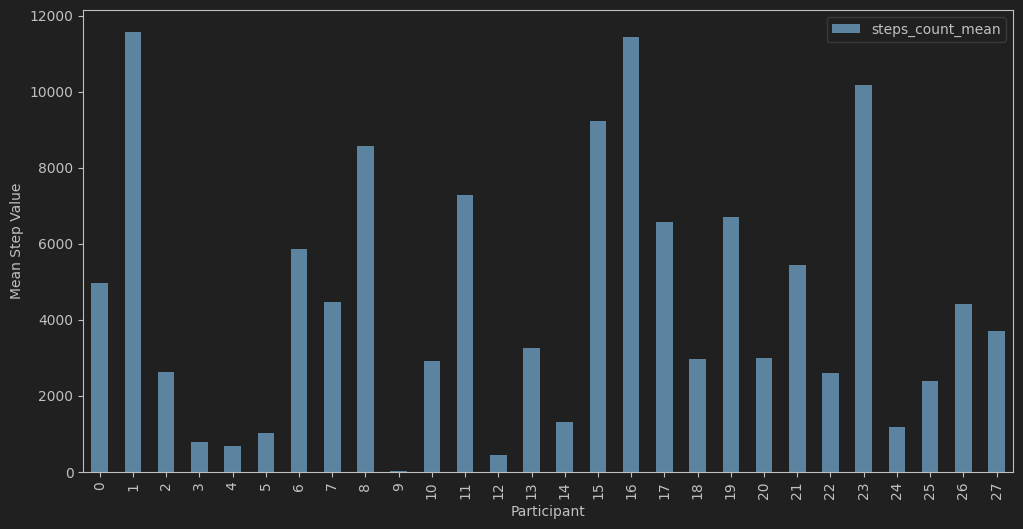

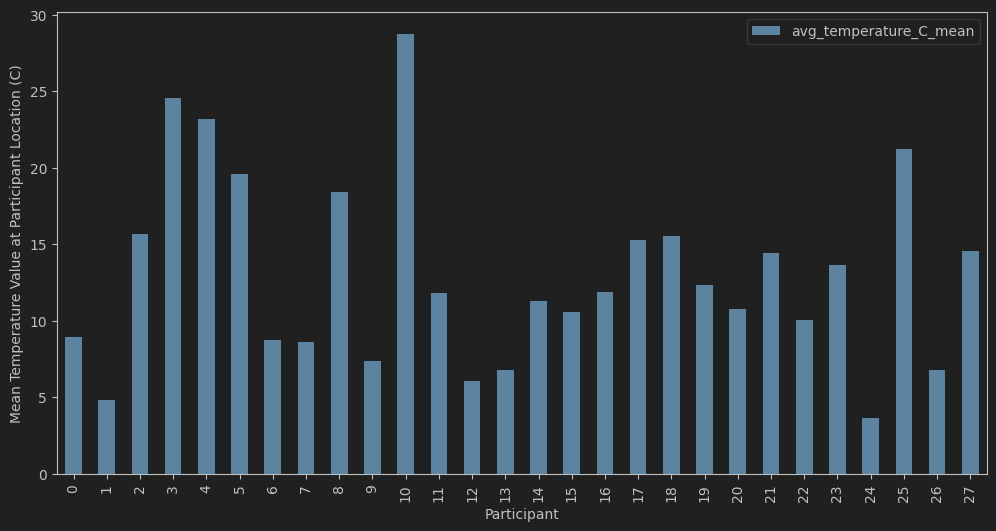

Plotting as imperfect scatterplots of precipitation, humidiy, or average temperature against daily steps we have the following image:

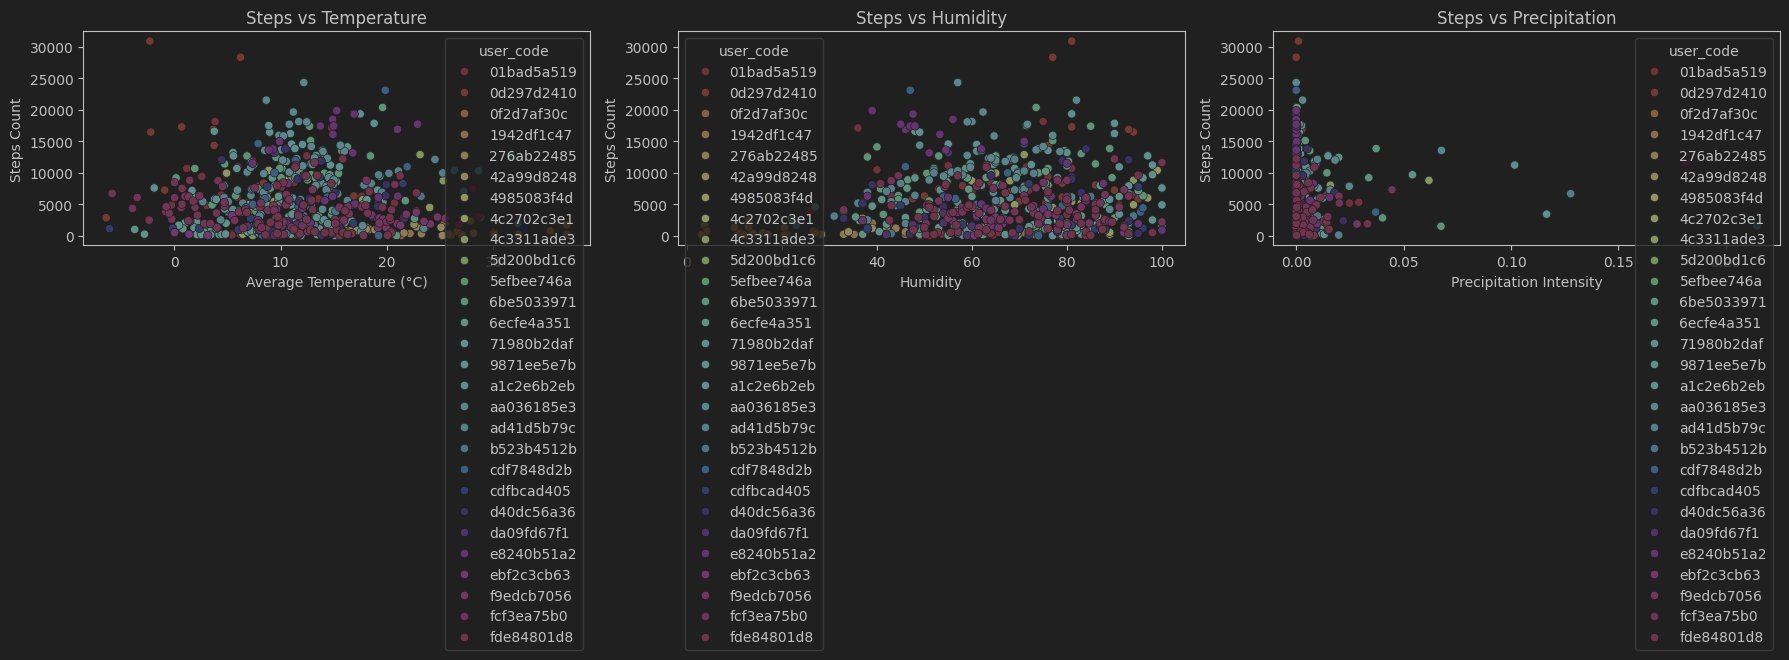

## Unique Feature (Not Implemented but desired)
Using python package `datetime` could extract the day of the week and label as weekend or weekday.
New binary feature: Weekend vs. weekday flag (`is_weekend`).
**Rationale**: Weather effects may manifest differently on workdays vs. leisure days, since discretionary activity is more weather-sensitive.
Planned (but also unfinished): Baseline deviation feature (steps relative to each user’s mean).
**Rationale**: Normalizes across heterogeneous step baselines, allowing clearer weather–behavior comparisons.

## Variable Relationships

Data quality was generally high, with weather features fully complete. Missingness was concentrated in wearable step data, reflecting non-adherence (not wearing devices).
Relationships between weather and steps were weak in aggregate, but variance across individuals was substantial—suggesting personalized or contextual modifiers (occupation, fitness habits, etc.).
Limitations: Incomplete wearable adherence reduces coverage; no demographic breakdown prevents subgroup analysis.
Strengths: Data provenance is robust, integrity across merges is maintained, and new features (weekend/weekday splits) add interpretability
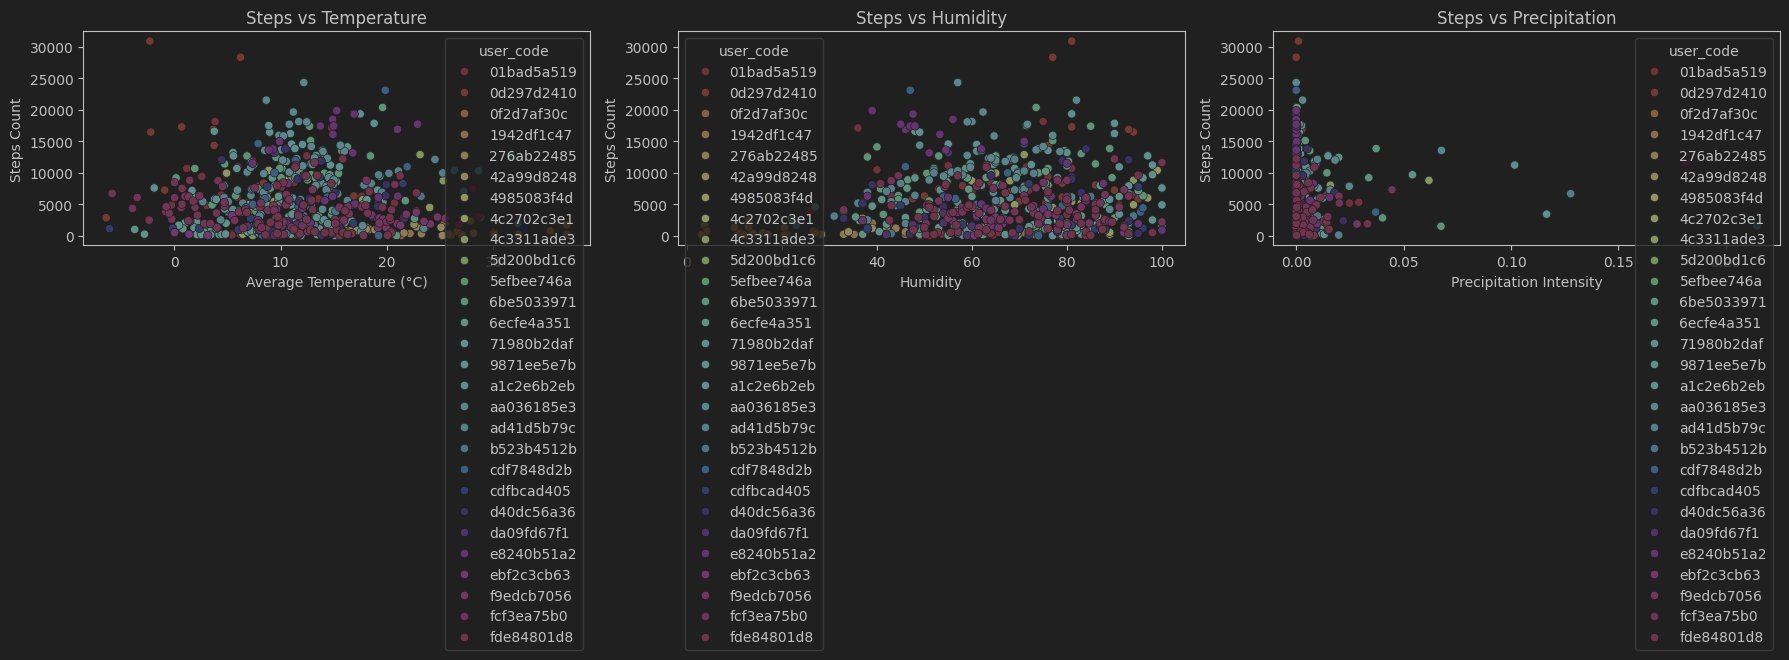
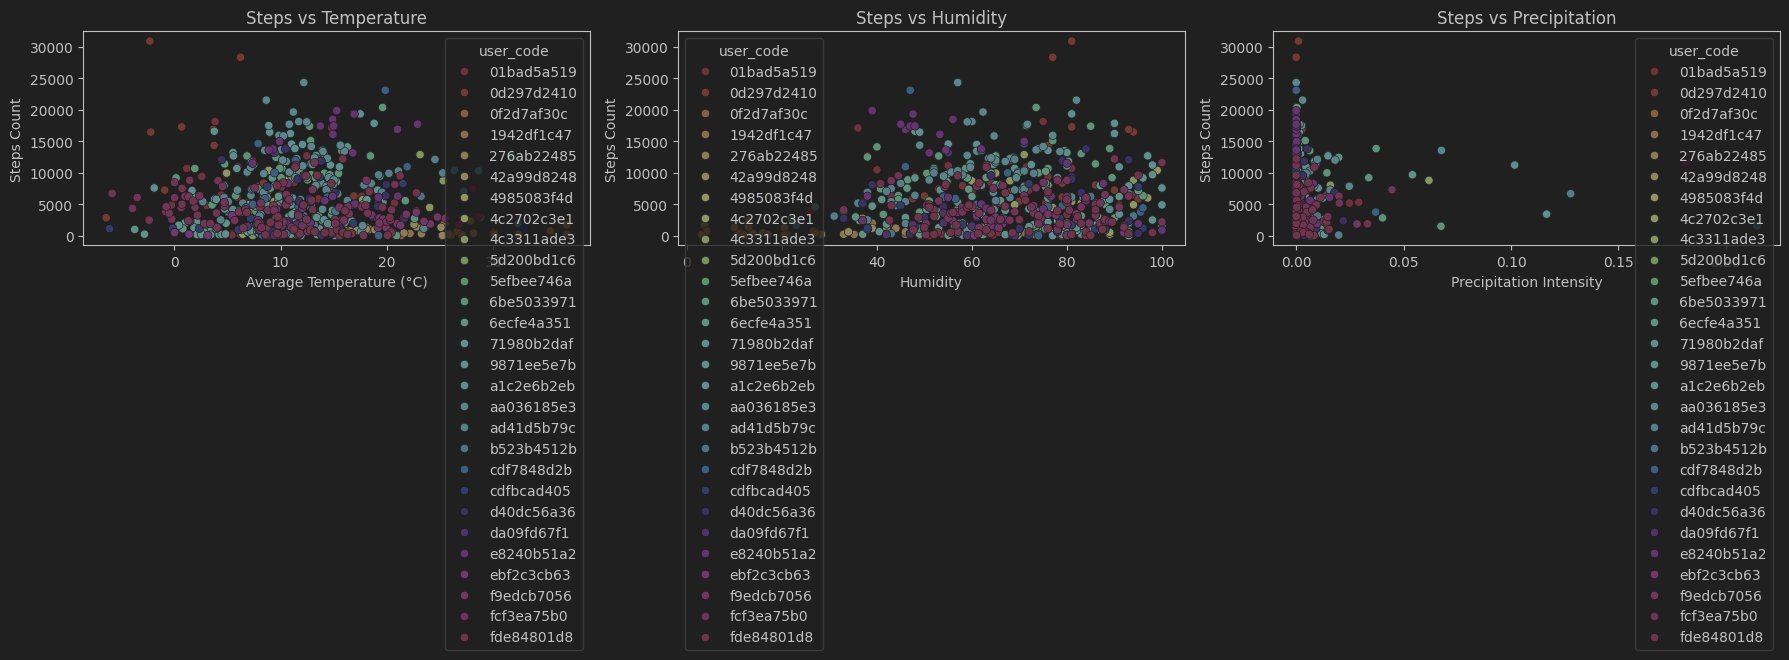

# Discussion

This analysis successfully merged environmental and wearable datasets to explore behavioral correlations. While no universal strong relationship was found, the work established:
1. Feasibility: weather and wearables data can be merged with minimal data loss though the 2 hour time limit proved challenging.
2. Data quality: weather variables are reliable; wearables require stricter adherence.
3. Future directions: feature engineering (baseline-normalized steps, per-user models) may reveal individualized weather–activity links.